# KANDY XAI — Notebook 04
## Saliency Maps + SHAP

Nel Notebook 03 abbiamo confrontato ResNet-18 pretrained e scratch su tutte le 20 task.

Qui analizziamo cinque task rappresentative:

- Task 0 — triangle vs any
- Task 9 — red triangle on the right
- Task 13 — triangle and square, same color
- Task 14 — palindrome aba
- Task 19 — traffic light

Per ogni task analizziamo i checkpoint **pretrained** e **scratch**, concentrandoci su TP/FP/FN/TN quando disponibili.


## 1. Dipendenze

In [1]:
import sys
import ast
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

import shap

print("Python:", sys.version)
print("Executable:", sys.executable)
print("PyTorch:", torch.__version__)
print("SHAP:", shap.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


Python: 3.11.9 (main, Aug  7 2026, 13:00:06) [GCC 16.1.1 20260728]
Executable: /home/cosimo/Downloads/kandy-xai/.venv/bin/python
PyTorch: 2.13.0+cu130
SHAP: 0.51.0
Device: cpu


In [18]:
SEED = 12345
TASKS_FOR_XAI = [0, 9, 13, 14, 19]
MODEL_VARIANTS = ["pretrained", "scratch"]

IMAGE_SIZE = 224

SHAPES = ["triangle", "square", "circle"]
COLORS = ["red", "green", "blue", "cyan", "magenta", "yellow"]

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "samples" / "sets"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

CNN_RESULTS_DIR = PROJECT_ROOT / "results" / "cnn_benchmark"
CHECKPOINT_DIR = CNN_RESULTS_DIR / "checkpoints_final"
PREDICTION_DIR = CNN_RESULTS_DIR / "predictions"

XAI_RESULTS_DIR = PROJECT_ROOT / "results" / "xai"
SALIENCY_DIR = XAI_RESULTS_DIR / "saliency"
SHAP_DIR = XAI_RESULTS_DIR / "shap"

for d in [XAI_RESULTS_DIR, SALIENCY_DIR, SHAP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


Device: cpu


In [3]:
TASK_NAMES = {
    0: "triangle vs any",
    1: "square vs any",
    2: "circle vs any",
    3: "red vs any",
    4: "green vs any",
    5: "blue vs any",
    6: "cyan vs any",
    7: "magenta vs any",
    8: "yellow vs any",
    9: "red triangle on the right",
    10: "red triangle on the right and arbitrary objects",
    11: "red triangle on the right and at least one circle and arbitrary objects",
    12: "red triangle on the right and at least one blue object and arbitrary objects",
    13: "triangle and square, same color",
    14: "palindrome aba",
    15: "house",
    16: "car",
    17: "tower",
    18: "wagon",
    19: "traffic light",
}

for i in TASKS_FOR_XAI:
    print(f"Task {i}: {TASK_NAMES[i]}")


Task 0: triangle vs any
Task 9: red triangle on the right
Task 13: triangle and square, same color
Task 14: palindrome aba
Task 19: traffic light


In [4]:
train_all = pd.read_csv(TRAIN_DIR / "annotations.csv")
val_all = pd.read_csv(VAL_DIR / "annotations.csv")
test_all = pd.read_csv(TEST_DIR / "annotations.csv")

benchmark_results = pd.read_csv(
    CNN_RESULTS_DIR / "cnn_benchmark_results.csv"
)

display(
    benchmark_results[
        benchmark_results.task_id.isin(TASKS_FOR_XAI)
    ][
        [
            "task_id", "task_name", "variant",
            "test_accuracy", "test_precision",
            "test_recall", "test_f1"
        ]
    ]
)


,task_id,task_name,variant,test_accuracy,test_precision,test_recall,test_f1
0,0,triangle vs any,pretrained,0.96,0.875000,1.000000,0.933333
1,0,triangle vs any,scratch,0.28,0.280000,1.000000,0.437500
18,9,red triangle on the right,pretrained,1.00,1.000000,1.000000,1.000000
19,9,red triangle on the right,scratch,0.32,0.320000,1.000000,0.484848
26,13,"triangle and square, same color",pretrained,0.44,0.615385,0.470588,0.533333
27,13,"triangle and square, same color",scratch,0.24,0.000000,0.000000,0.000000
28,14,palindrome aba,pretrained,0.36,0.300000,0.250000,0.272727
29,14,palindrome aba,scratch,0.48,0.480000,1.000000,0.648649
38,19,traffic light,pretrained,0.96,0.750000,1.000000,0.857143
39,19,traffic light,scratch,0.88,0.000000,0.000000,0.000000


## 2. Modello e preprocessing

In [5]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN.tolist(),
        IMAGENET_STD.tolist(),
    ),
])

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model.to(DEVICE)

def load_model(task_id, variant):
    path = (
        CHECKPOINT_DIR
        / f"task_{task_id:02d}_{variant}_best.pt"
    )

    if not path.exists():
        raise FileNotFoundError(path)

    model = build_model()

    checkpoint = torch.load(
        path,
        map_location=DEVICE,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
    model.eval()

    return model

def load_image(split, filename):
    base = {
        "train": TRAIN_DIR,
        "val": VAL_DIR,
        "test": TEST_DIR,
    }[split]

    return Image.open(
        base / filename
    ).convert("RGB")

def preprocess_image(image):
    return eval_transform(image)

def predict_image(model, image):
    x = preprocess_image(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        p = torch.softmax(model(x), dim=1)[0]

    prediction = int(p.argmax())
    probability_positive = float(p[1])

    return prediction, probability_positive


## 3. Selezione dei casi

Per ogni task/modello scegliamo il caso più sicuro disponibile di ciascuna categoria:

- TP
- FP
- FN
- TN

Questo rende l'analisi XAI utile anche per gli errori.


In [6]:
def load_predictions(task_id, variant):
    return pd.read_csv(
        PREDICTION_DIR
        / f"task_{task_id:02d}_{variant}_predictions.csv"
    )

def select_cases(df):
    groups = {
        "TP": (df.true_label == 1) & (df.prediction == 1),
        "FP": (df.true_label == 0) & (df.prediction == 1),
        "FN": (df.true_label == 1) & (df.prediction == 0),
        "TN": (df.true_label == 0) & (df.prediction == 0),
    }

    cases = {}

    for name, mask in groups.items():
        subset = df[mask]

        if len(subset):
            idx = (
                subset["probability_positive"]
                .sub(0.5)
                .abs()
                .idxmax()
            )
            cases[name] = subset.loc[idx]

    return cases

selected_cases = {}

for task_id in TASKS_FOR_XAI:
    for variant in MODEL_VARIANTS:
        df = load_predictions(task_id, variant)
        selected_cases[(task_id, variant)] = select_cases(df)

        print(f"\nTask {task_id} | {variant}")
        for case, row in selected_cases[(task_id, variant)].items():
            print(
                f"{case}: {row['filename']} | "
                f"y={int(row['true_label'])} | "
                f"p={row['probability_positive']:.3f}"
            )



Task 0 | pretrained
TP: 0/0003.png | y=1 | p=1.000
FP: 0/0019.png | y=0 | p=0.591
TN: 0/0013.png | y=0 | p=0.000

Task 0 | scratch
TP: 0/0010.png | y=1 | p=0.679
FP: 0/0012.png | y=0 | p=0.682

Task 9 | pretrained
TP: 9/0016.png | y=1 | p=0.992
TN: 9/0012.png | y=0 | p=0.000

Task 9 | scratch
TP: 9/0004.png | y=1 | p=0.690
FP: 9/0010.png | y=0 | p=0.686

Task 13 | pretrained
TP: 13/0010.png | y=1 | p=0.937
FP: 13/0022.png | y=0 | p=0.832
FN: 13/0023.png | y=1 | p=0.154
TN: 13/0000.png | y=0 | p=0.119

Task 13 | scratch
FP: 13/0021.png | y=0 | p=0.591
FN: 13/0004.png | y=1 | p=0.420
TN: 13/0013.png | y=0 | p=0.426

Task 14 | pretrained
TP: 14/0008.png | y=1 | p=0.709
FP: 14/0007.png | y=0 | p=0.744
FN: 14/0024.png | y=1 | p=0.168
TN: 14/0001.png | y=0 | p=0.169

Task 14 | scratch
TP: 14/0021.png | y=1 | p=0.602
FP: 14/0017.png | y=0 | p=0.606

Task 19 | pretrained
TP: 19/0022.png | y=1 | p=0.995
FP: 19/0006.png | y=0 | p=0.646
TN: 19/0017.png | y=0 | p=0.000

Task 19 | scratch
FN: 19/0

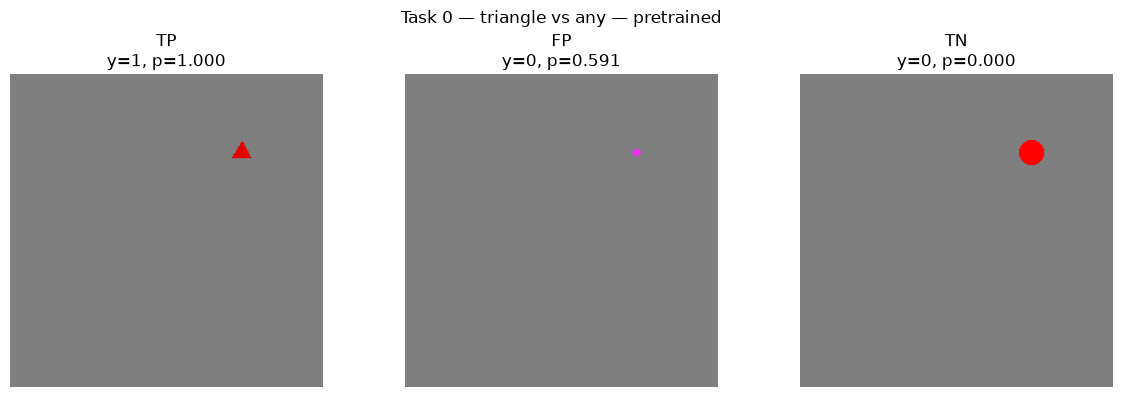

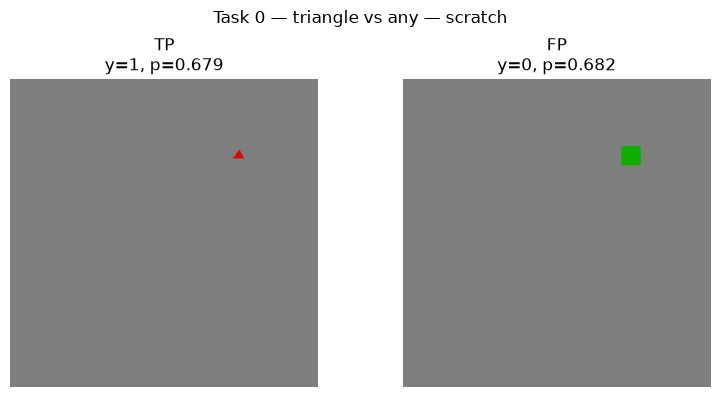

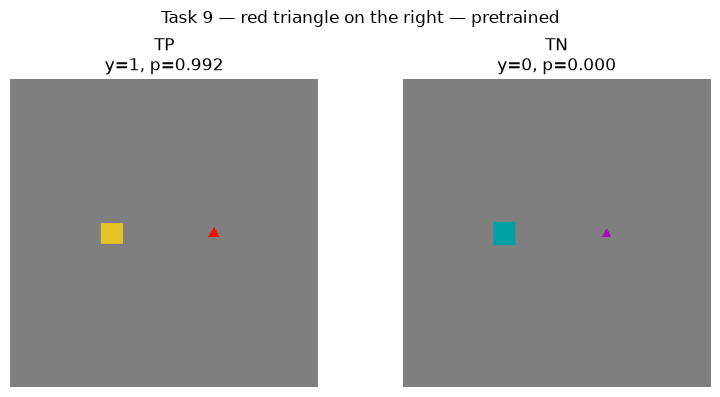

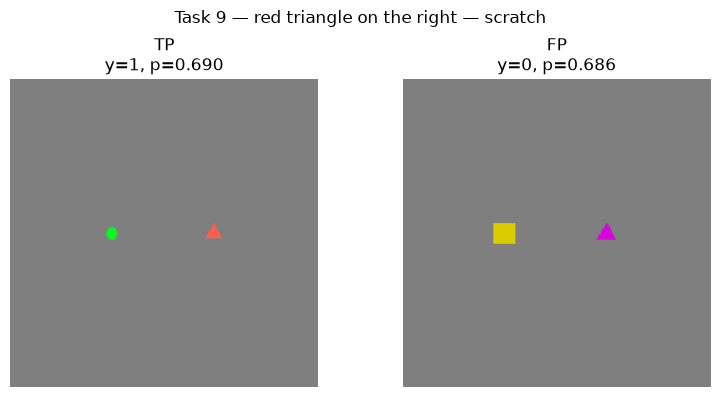

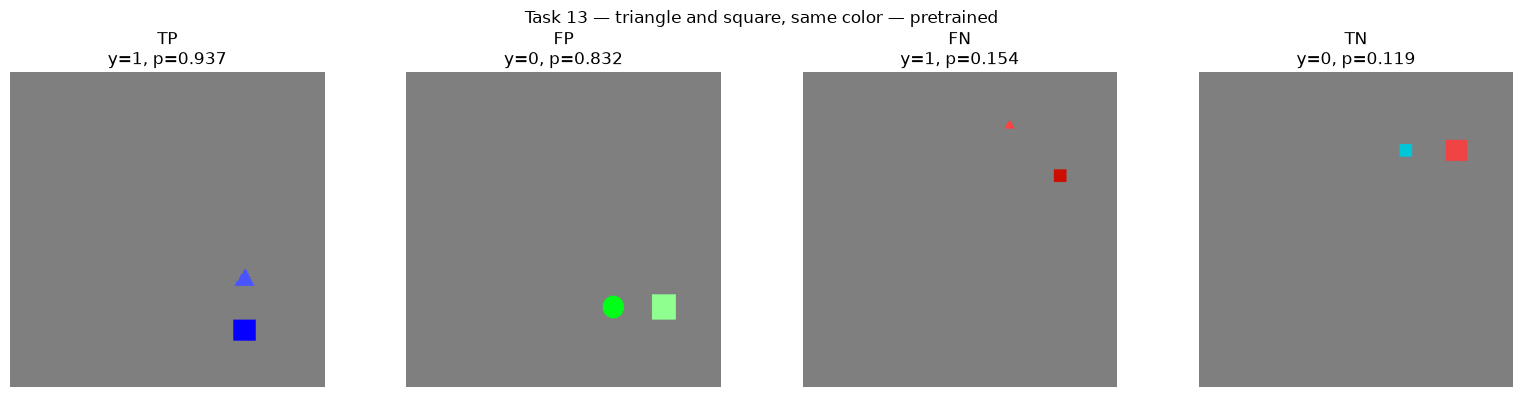

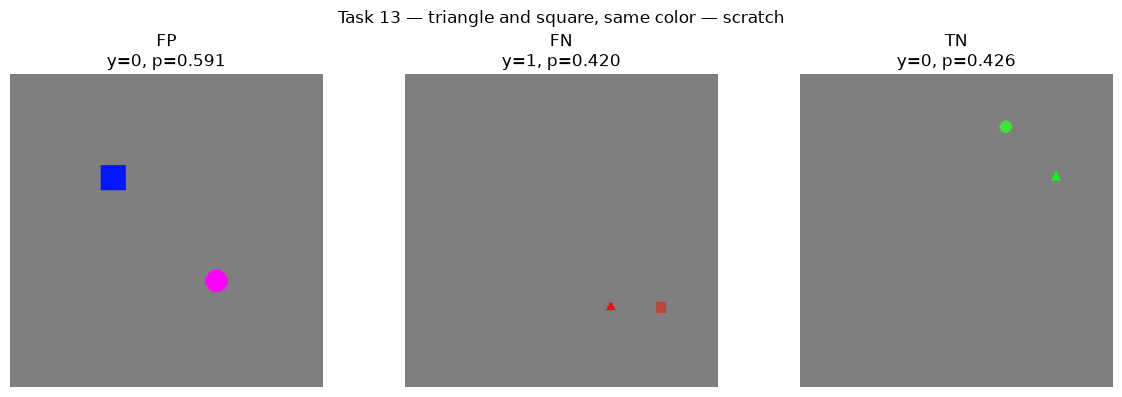

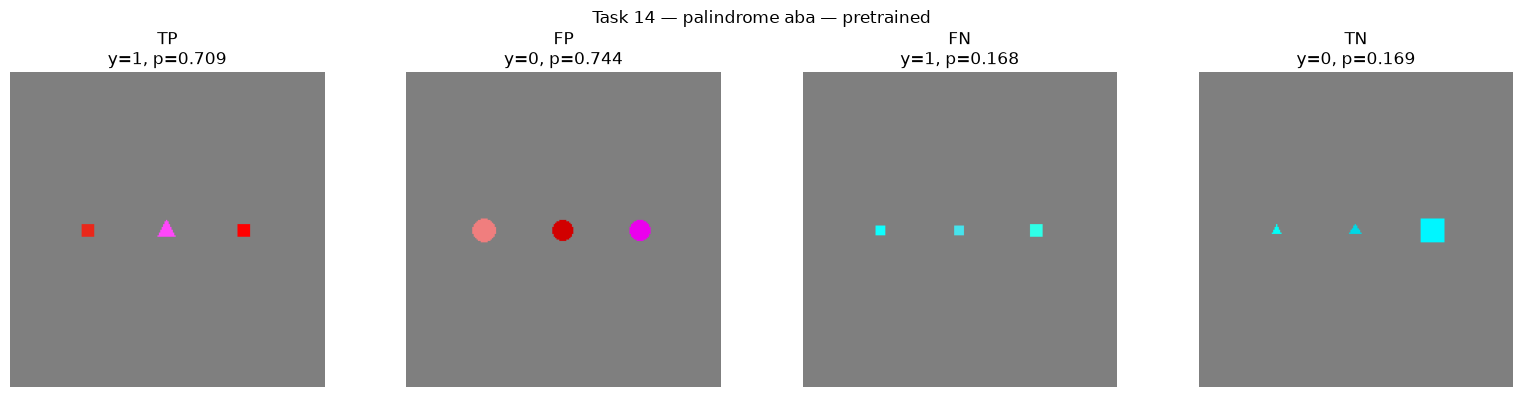

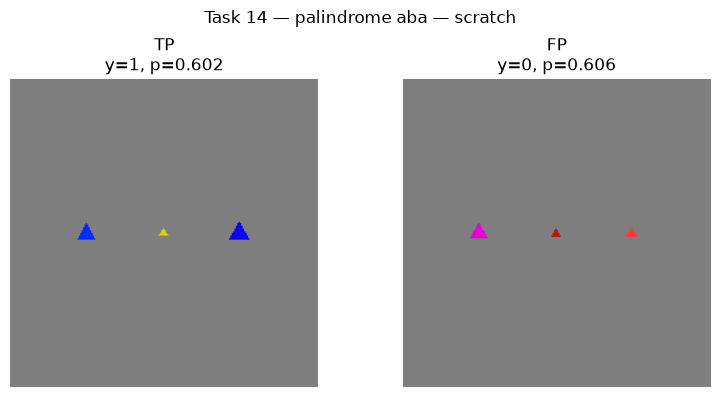

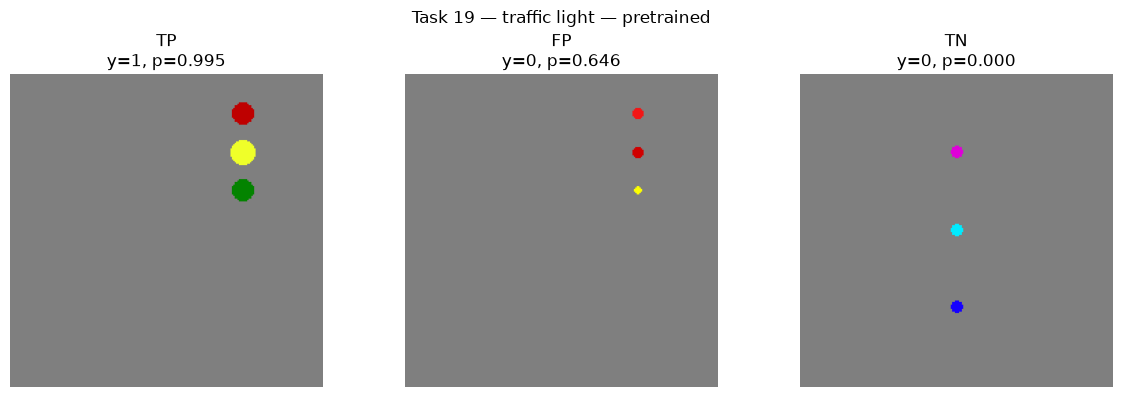

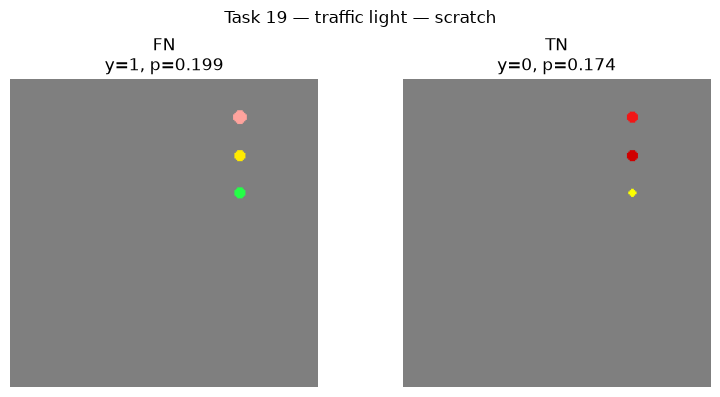

In [7]:
def show_selected_cases(task_id, variant):
    cases = selected_cases[(task_id, variant)]

    if not cases:
        return

    fig, axes = plt.subplots(
        1, len(cases),
        figsize=(4 * len(cases), 4)
    )

    if len(cases) == 1:
        axes = [axes]

    for ax, (case, row) in zip(axes, cases.items()):
        image = load_image("test", row["filename"])
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(
            f"{case}\n"
            f"y={int(row['true_label'])}, "
            f"p={row['probability_positive']:.3f}"
        )

    fig.suptitle(
        f"Task {task_id} — {TASK_NAMES[task_id]} — {variant}"
    )
    plt.tight_layout()
    plt.show()

for task_id in TASKS_FOR_XAI:
    for variant in MODEL_VARIANTS:
        show_selected_cases(task_id, variant)


# 4. Vanilla Gradient Saliency

Calcoliamo:

```text
| ∂ logit(target) / ∂ pixel |
```

La mappa mostra quali pixel hanno grande sensibilità rispetto alla logit della classe spiegata.

È una tecnica post-hoc e non una garanzia di fedeltà alla regola.


In [8]:
def compute_saliency(model, image, target_class):
    x = (
        preprocess_image(image)
        .unsqueeze(0)
        .to(DEVICE)
    )
    x.requires_grad_(True)

    model.zero_grad(set_to_none=True)

    logits = model(x)
    target = logits[0, target_class]
    target.backward()

    gradients = (
        x.grad
        .detach()
        .cpu()
        .numpy()[0]
    )

    saliency = np.abs(gradients).max(axis=0)

    saliency -= saliency.min()

    if saliency.max() > 0:
        saliency /= saliency.max()

    return saliency

def plot_saliency(image, saliency, title):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(image)
    axes[0].axis("off")
    axes[0].set_title("Original")

    axes[1].imshow(image)
    axes[1].imshow(
        saliency,
        alpha=0.55,
        cmap="magma",
    )
    axes[1].axis("off")
    axes[1].set_title("Saliency")

    fig.suptitle(title)
    plt.tight_layout()

    return fig


In [9]:
saliency_records = []

for task_id in TASKS_FOR_XAI:
    for variant in MODEL_VARIANTS:

        model = load_model(task_id, variant)
        cases = selected_cases[(task_id, variant)]

        for case_type, row in cases.items():

            image = load_image(
                "test",
                row["filename"],
            )

            prediction = int(row["prediction"])

            saliency = compute_saliency(
                model,
                image,
                prediction,
            )

            output = (
                SALIENCY_DIR
                / f"task_{task_id:02d}_"
                  f"{variant}_{case_type}_"
                  f"{Path(row['filename']).stem}.png"
            )

            fig = plot_saliency(
                image,
                saliency,
                (
                    f"Task {task_id} | {variant} | "
                    f"{case_type} | "
                    f"y={int(row['true_label'])} | "
                    f"p={row['probability_positive']:.3f}"
                ),
            )

            fig.savefig(
                output,
                dpi=150,
                bbox_inches="tight",
            )
            plt.close(fig)

            saliency_records.append({
                "task_id": task_id,
                "variant": variant,
                "case_type": case_type,
                "filename": row["filename"],
                "true_label": int(row["true_label"]),
                "prediction": prediction,
                "probability_positive": float(
                    row["probability_positive"]
                ),
                "path": str(output),
            })

saliency_df = pd.DataFrame(saliency_records)

display(saliency_df)


,task_id,variant,case_type,filename,true_label,prediction,probability_positive,path
0,0,pretrained,TP,0/0003.png,1,1,1.000000,/home/cosimo/Downloads/kandy-xai/results/xai/s...
1,0,pretrained,FP,0/0019.png,0,1,0.590670,/home/cosimo/Downloads/kandy-xai/results/xai/s...
2,0,pretrained,TN,0/0013.png,0,0,0.000129,/home/cosimo/Downloads/kandy-xai/results/xai/s...
3,0,scratch,TP,0/0010.png,1,1,0.679354,/home/cosimo/Downloads/kandy-xai/results/xai/s...
4,0,scratch,FP,0/0012.png,0,1,0.682188,/home/cosimo/Downloads/kandy-xai/results/xai/s...
5,9,pretrained,TP,9/0016.png,1,1,0.992418,/home/cosimo/Downloads/kandy-xai/results/xai/s...
6,9,pretrained,TN,9/0012.png,0,0,0.000339,/home/cosimo/Downloads/kandy-xai/results/xai/s...
7,9,scratch,TP,9/0004.png,1,1,0.689666,/home/cosimo/Downloads/kandy-xai/results/xai/s...
8,9,scratch,FP,9/0010.png,0,1,0.686034,/home/cosimo/Downloads/kandy-xai/results/xai/s...
9,13,pretrained,TP,13/0010.png,1,1,0.937293,/home/cosimo/Downloads/kandy-xai/results/xai/s...


# 5. SHAP

Usiamo `shap.GradientExplainer`.

Il background è costituito da 8 immagini del **training set della stessa task**, scelte deterministically con il seed.

Per ogni caso selezionato spieghiamo la probabilità della classe predetta.


In [10]:
def build_background(task_id, n_background=8):
    df = train_all[
        train_all.task_id == task_id
    ].reset_index(drop=True)

    rows = df.sample(
        n=min(n_background, len(df)),
        random_state=SEED,
    )

    tensors = []

    for _, row in rows.iterrows():
        image = load_image(
            "train",
            row["filename"],
        )
        tensors.append(
            preprocess_image(image)
        )

    return torch.stack(tensors).to(DEVICE)

class ProbabilityModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return torch.softmax(
            self.model(x),
            dim=1,
        )

def compute_shap(
    model,
    background,
    image_tensor,
):
    wrapper = ProbabilityModel(model).eval()

    explainer = shap.GradientExplainer(
        wrapper,
        background,
    )

    return explainer.shap_values(
        image_tensor
    )


In [11]:
def extract_class_shap(shap_values, class_index):
    if isinstance(shap_values, list):
        values = np.asarray(
            shap_values[class_index]
        )
    else:
        values = np.asarray(shap_values)

        if values.ndim == 5:
            if values.shape[-1] == 2:
                values = values[..., class_index]
            elif values.shape[1] == 2:
                values = values[:, class_index]
            else:
                raise ValueError(
                    f"Formato SHAP non riconosciuto: {values.shape}"
                )

    if values.ndim == 4:
        values = values[0]

    if values.ndim == 3 and values.shape[0] == 3:
        values = values.transpose(1, 2, 0)

    if values.ndim != 3:
        raise ValueError(
            f"Shape SHAP finale non riconosciuta: {values.shape}"
        )

    return values


def plot_shap(image, shap_values, title):
    magnitude = np.abs(shap_values).sum(axis=-1)

    signed = shap_values.sum(axis=-1)

    vmax_mag = max(
        np.percentile(magnitude, 99),
        1e-8,
    )

    vmax_signed = max(
        np.percentile(np.abs(signed), 99),
        1e-8,
    )

    fig, axes = plt.subplots(
        1, 3,
        figsize=(12, 4),
    )

    axes[0].imshow(image)
    axes[0].axis("off")
    axes[0].set_title("Original")

    axes[1].imshow(image)
    axes[1].imshow(
        magnitude,
        alpha=0.6,
        cmap="magma",
        vmin=0,
        vmax=vmax_mag,
    )
    axes[1].axis("off")
    axes[1].set_title("|SHAP|")

    axes[2].imshow(
        signed,
        cmap="coolwarm",
        vmin=-vmax_signed,
        vmax=vmax_signed,
    )
    axes[2].axis("off")
    axes[2].set_title("Signed SHAP")

    fig.suptitle(title)
    plt.tight_layout()

    return fig


In [12]:
shap_records = []

for task_id in TASKS_FOR_XAI:

    print(
        f"\n===== Task {task_id}: "
        f"{TASK_NAMES[task_id]} ====="
    )

    background = build_background(
        task_id,
        n_background=8,
    )

    for variant in MODEL_VARIANTS:

        model = load_model(
            task_id,
            variant,
        )

        cases = selected_cases[
            (task_id, variant)
        ]

        for case_type, row in cases.items():

            print(
                f"{variant} | {case_type} | "
                f"{row['filename']}"
            )

            image = load_image(
                "test",
                row["filename"],
            )

            x = (
                preprocess_image(image)
                .unsqueeze(0)
                .to(DEVICE)
            )

            prediction = int(
                row["prediction"]
            )

            shap_values = compute_shap(
                model,
                background,
                x,
            )

            class_values = extract_class_shap(
                shap_values,
                prediction,
            )

            output = (
                SHAP_DIR
                / f"task_{task_id:02d}_"
                  f"{variant}_{case_type}_"
                  f"{Path(row['filename']).stem}.png"
            )

            fig = plot_shap(
                image,
                class_values,
                (
                    f"Task {task_id} | {variant} | "
                    f"{case_type} | "
                    f"y={int(row['true_label'])} | "
                    f"p={row['probability_positive']:.3f}"
                ),
            )

            fig.savefig(
                output,
                dpi=150,
                bbox_inches="tight",
            )
            plt.close(fig)

            shap_records.append({
                "task_id": task_id,
                "variant": variant,
                "case_type": case_type,
                "filename": row["filename"],
                "true_label": int(row["true_label"]),
                "prediction": prediction,
                "probability_positive": float(
                    row["probability_positive"]
                ),
                "path": str(output),
            })

shap_df = pd.DataFrame(shap_records)

display(shap_df)



===== Task 0: triangle vs any =====
pretrained | TP | 0/0003.png
pretrained | FP | 0/0019.png
pretrained | TN | 0/0013.png
scratch | TP | 0/0010.png
scratch | FP | 0/0012.png

===== Task 9: red triangle on the right =====
pretrained | TP | 9/0016.png
pretrained | TN | 9/0012.png
scratch | TP | 9/0004.png
scratch | FP | 9/0010.png

===== Task 13: triangle and square, same color =====
pretrained | TP | 13/0010.png
pretrained | FP | 13/0022.png
pretrained | FN | 13/0023.png
pretrained | TN | 13/0000.png
scratch | FP | 13/0021.png
scratch | FN | 13/0004.png
scratch | TN | 13/0013.png

===== Task 14: palindrome aba =====
pretrained | TP | 14/0008.png
pretrained | FP | 14/0007.png
pretrained | FN | 14/0024.png
pretrained | TN | 14/0001.png
scratch | TP | 14/0021.png
scratch | FP | 14/0017.png

===== Task 19: traffic light =====
pretrained | TP | 19/0022.png
pretrained | FP | 19/0006.png
pretrained | TN | 19/0017.png
scratch | FN | 19/0007.png
scratch | TN | 19/0006.png


,task_id,variant,case_type,filename,true_label,prediction,probability_positive,path
0,0,pretrained,TP,0/0003.png,1,1,1.000000,/home/cosimo/Downloads/kandy-xai/results/xai/s...
1,0,pretrained,FP,0/0019.png,0,1,0.590670,/home/cosimo/Downloads/kandy-xai/results/xai/s...
2,0,pretrained,TN,0/0013.png,0,0,0.000129,/home/cosimo/Downloads/kandy-xai/results/xai/s...
3,0,scratch,TP,0/0010.png,1,1,0.679354,/home/cosimo/Downloads/kandy-xai/results/xai/s...
4,0,scratch,FP,0/0012.png,0,1,0.682188,/home/cosimo/Downloads/kandy-xai/results/xai/s...
5,9,pretrained,TP,9/0016.png,1,1,0.992418,/home/cosimo/Downloads/kandy-xai/results/xai/s...
6,9,pretrained,TN,9/0012.png,0,0,0.000339,/home/cosimo/Downloads/kandy-xai/results/xai/s...
7,9,scratch,TP,9/0004.png,1,1,0.689666,/home/cosimo/Downloads/kandy-xai/results/xai/s...
8,9,scratch,FP,9/0010.png,0,1,0.686034,/home/cosimo/Downloads/kandy-xai/results/xai/s...
9,13,pretrained,TP,13/0010.png,1,1,0.937293,/home/cosimo/Downloads/kandy-xai/results/xai/s...


# 6. Confronto delle spiegazioni

La domanda è se i due modelli si concentrano sulle stesse regioni e, soprattutto, se quelle regioni corrispondono alla regola KANDY.


In [13]:
def show_explanation_file(path, title):
    if not Path(path).exists():
        print("File non trovato:", path)
        return

    image = Image.open(path)

    plt.figure(figsize=(7, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(title)
    plt.show()

def compare_available_explanations(
    task_id,
    case_type,
):
    print(
        f"Task {task_id} — {case_type}"
    )

    for variant in MODEL_VARIANTS:

        row = selected_cases[
            (task_id, variant)
        ].get(case_type)

        if row is None:
            print(
                f"{variant}: caso non disponibile"
            )
            continue

        stem = Path(
            row["filename"]
        ).stem

        saliency_path = (
            SALIENCY_DIR
            / f"task_{task_id:02d}_"
              f"{variant}_{case_type}_{stem}.png"
        )

        shap_path = (
            SHAP_DIR
            / f"task_{task_id:02d}_"
              f"{variant}_{case_type}_{stem}.png"
        )

        print(
            f"{variant}: {row['filename']}"
        )

        if saliency_path.exists():
            show_explanation_file(
                saliency_path,
                f"{variant} — Saliency",
            )

        if shap_path.exists():
            show_explanation_file(
                shap_path,
                f"{variant} — SHAP",
            )


## 7. Statistiche descrittive della saliency

Calcoliamo alcune misure semplici:

- media;
- massimo;
- frazione di pixel ad alta saliency;
- centro di massa.


In [14]:
def saliency_statistics(saliency):
    saliency = np.asarray(
        saliency,
        dtype=float,
    )

    saliency = np.maximum(
        saliency,
        0,
    )

    total = saliency.sum()

    if total <= 0:
        return {
            "mean": 0.0,
            "max": 0.0,
            "high_saliency_fraction": 0.0,
            "center_x": 0.5,
            "center_y": 0.5,
        }

    normalized = (
        saliency / saliency.max()
        if saliency.max() > 0
        else saliency
    )

    y, x = np.indices(
        saliency.shape
    )

    center_x = (
        (x * saliency).sum()
        / total
        / saliency.shape[1]
    )

    center_y = (
        (y * saliency).sum()
        / total
        / saliency.shape[0]
    )

    return {
        "mean": float(saliency.mean()),
        "max": float(saliency.max()),
        "high_saliency_fraction": float(
            (normalized >= 0.8).mean()
        ),
        "center_x": float(center_x),
        "center_y": float(center_y),
    }


In [15]:
stats_rows = []

for task_id in TASKS_FOR_XAI:
    for variant in MODEL_VARIANTS:

        model = load_model(
            task_id,
            variant,
        )

        for case_type, row in selected_cases[
            (task_id, variant)
        ].items():

            image = load_image(
                "test",
                row["filename"],
            )

            saliency = compute_saliency(
                model,
                image,
                int(row["prediction"]),
            )

            stats_rows.append({
                "task_id": task_id,
                "task_name": TASK_NAMES[task_id],
                "variant": variant,
                "case_type": case_type,
                "filename": row["filename"],
                **saliency_statistics(saliency),
            })

saliency_stats_df = pd.DataFrame(stats_rows)

saliency_stats_path = (
    XAI_RESULTS_DIR
    / "saliency_statistics.csv"
)

saliency_stats_df.to_csv(
    saliency_stats_path,
    index=False,
)

display(saliency_stats_df)


,task_id,task_name,variant,case_type,filename,mean,max,high_saliency_fraction,center_x,center_y
0,0,triangle vs any,pretrained,TP,0/0003.png,0.012802,1.0,0.000020,0.686311,0.286667
1,0,triangle vs any,pretrained,FP,0/0019.png,0.005086,1.0,0.000100,0.722601,0.265959
2,0,triangle vs any,pretrained,TN,0/0013.png,0.027803,1.0,0.000219,0.640207,0.355383
3,0,triangle vs any,scratch,TP,0/0010.png,0.144728,1.0,0.000020,0.479456,0.464891
4,0,triangle vs any,scratch,FP,0/0012.png,0.156931,1.0,0.000239,0.485066,0.457991
5,9,red triangle on the right,pretrained,TP,9/0016.png,0.012796,1.0,0.000060,0.623795,0.445575
6,9,red triangle on the right,pretrained,TN,9/0012.png,0.020988,1.0,0.000040,0.563471,0.435167
7,9,red triangle on the right,scratch,TP,9/0004.png,0.147639,1.0,0.000159,0.468098,0.459253
8,9,red triangle on the right,scratch,FP,9/0010.png,0.123582,1.0,0.000040,0.466146,0.460368
9,13,"triangle and square, same color",pretrained,TP,13/0010.png,0.050647,1.0,0.000299,0.357388,0.555197


# 8. Collegamento alle annotazioni simboliche

La colonna `symbol` contiene la descrizione strutturale generata da KANDY, ad esempio:

```text
{'quadrant_lr': [
    {'shape': 'triangle',
     'color': 'blue',
     'size': 'large'}
]}
```

Queste annotazioni sono il riferimento simbolico con cui confronteremo le spiegazioni.

In questo notebook non trasformiamo ancora automaticamente una heatmap in una misura di fedeltà: questo sarà il passo successivo.


In [16]:
def get_symbol(filename):
    rows = test_all[
        test_all.filename == filename
    ]

    if len(rows) == 0:
        return None

    return rows.iloc[0]["symbol"]


selected_rows = []

for (task_id, variant), cases in selected_cases.items():

    for case_type, row in cases.items():

        selected_rows.append({
            "task_id": task_id,
            "task_name": TASK_NAMES[task_id],
            "variant": variant,
            "case_type": case_type,
            "filename": row["filename"],
            "true_label": int(row["true_label"]),
            "prediction": int(row["prediction"]),
            "probability_positive": float(
                row["probability_positive"]
            ),
            "confidence": float(
                row["confidence"]
            ),
            "symbol": get_symbol(
                row["filename"]
            ),
        })

selected_cases_df = pd.DataFrame(
    selected_rows
)

selected_cases_path = (
    XAI_RESULTS_DIR
    / "selected_cases.csv"
)

selected_cases_df.to_csv(
    selected_cases_path,
    index=False,
)

display(selected_cases_df)


,task_id,task_name,variant,case_type,filename,true_label,prediction,probability_positive,confidence,symbol
0,0,triangle vs any,pretrained,TP,0/0003.png,1,1,1.000000,0.500000,"{'quadrant_ur': [{'shape': 'triangle', 'color'..."
1,0,triangle vs any,pretrained,FP,0/0019.png,0,1,0.590670,0.090670,"{'quadrant_ll': [{'shape': 'circle', 'color': ..."
2,0,triangle vs any,pretrained,TN,0/0013.png,0,0,0.000129,0.499871,"{'quadrant_ll': [{'shape': 'circle', 'color': ..."
3,0,triangle vs any,scratch,TP,0/0010.png,1,1,0.679354,0.179354,"{'quadrant_ur': [{'shape': 'triangle', 'color'..."
4,0,triangle vs any,scratch,FP,0/0012.png,0,1,0.682188,0.182188,"{'quadrant_ll': [{'shape': 'square', 'color': ..."
5,9,red triangle on the right,pretrained,TP,9/0016.png,1,1,0.992418,0.492418,"{'side_by_side': [{'shape': 'square', 'color':..."
6,9,red triangle on the right,pretrained,TN,9/0012.png,0,0,0.000339,0.499661,"{'side_by_side': [{'shape': 'square', 'color':..."
7,9,red triangle on the right,scratch,TP,9/0004.png,1,1,0.689666,0.189666,"{'side_by_side': [{'shape': 'circle', 'color':..."
8,9,red triangle on the right,scratch,FP,9/0010.png,0,1,0.686034,0.186034,"{'side_by_side': [{'shape': 'square', 'color':..."
9,13,"triangle and square, same color",pretrained,TP,13/0010.png,1,1,0.937293,0.437293,{'quadrant_lr': [{'stack': [{'shape': 'triangl...


# 10. Output del notebook

Alla fine avremo:

```text
results/
└── xai/
    ├── selected_cases.csv
    ├── saliency_statistics.csv
    ├── saliency/
    │   └── heatmap PNG
    └── shap/
        └── SHAP PNG
```

## Cosa possiamo confrontare

Possiamo analizzare:

- pretrained vs scratch;
- TP vs FP vs FN vs TN;
- Saliency vs SHAP;
- attivazioni interne della ResNet;
- spiegazioni e annotazioni simboliche KANDY.

## Cosa NON possiamo concludere

Una heatmap convincente, una correlazione tra un canale e un concept o una singola attivazione elevata **non dimostrano da sole** che la CNN abbia imparato una regola o che un neurone rappresenti in modo puro un concetto.

Per una verifica più forte servono esperimenti di grounding, interventi e analisi della fedeltà della regola. Questi aspetti vengono affrontati nel Notebook 5 attraverso il bottleneck concettuale e le manipolazioni esplicite dei concetti.
